# Runtime of the stitching algorithm

> Fill in a module description here

In [ ]:
#| hide
from NEST.preprocess import *
from NEST.tiles import *
from NEST.labels import *

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import time
matplotlib.rcParams["figure.dpi"] = 300

In [ ]:
mask_path = "../data/local/2025-06-04_IHC_51-1-5_2_Merged_ch00_no_BG_global_mask.npy"
ps = 0.539

In [ ]:
#| eval: false
global_mask = np.load(mask_path)

In [ ]:
#| eval: false
cell_labels_vector = []
n_labels = []
timings = []
start_idx = 5000

vector = np.array(list(range(20, 70, 5)))**2

for increment in range(20, 70, 5):
    region = global_mask[start_idx:start_idx+increment**2, start_idx:start_idx+increment**2]
    unique_non_zero = len(np.unique(region[region != 0]))
    start_time = time.time()
    cell_labels = expand_with_cap(
        region,
        spacing=ps,
        fixed_expand=5.0,
        max_area_ratio=5.0
    )
    elapsed = time.time() - start_time
    n_labels.append(unique_non_zero)
    timings.append(elapsed)
    cell_labels_vector.append(cell_labels)

Increment: 400, Time: 0.042 s
Increment: 625, Time: 0.138 s
Increment: 900, Time: 0.533 s
Increment: 1225, Time: 1.984 s
Increment: 1600, Time: 6.187 s
Increment: 2025, Time: 18.973 s
Increment: 2500, Time: 43.852 s
Increment: 3025, Time: 93.243 s
Increment: 3600, Time: 172.568 s
Increment: 4225, Time: 337.987 s


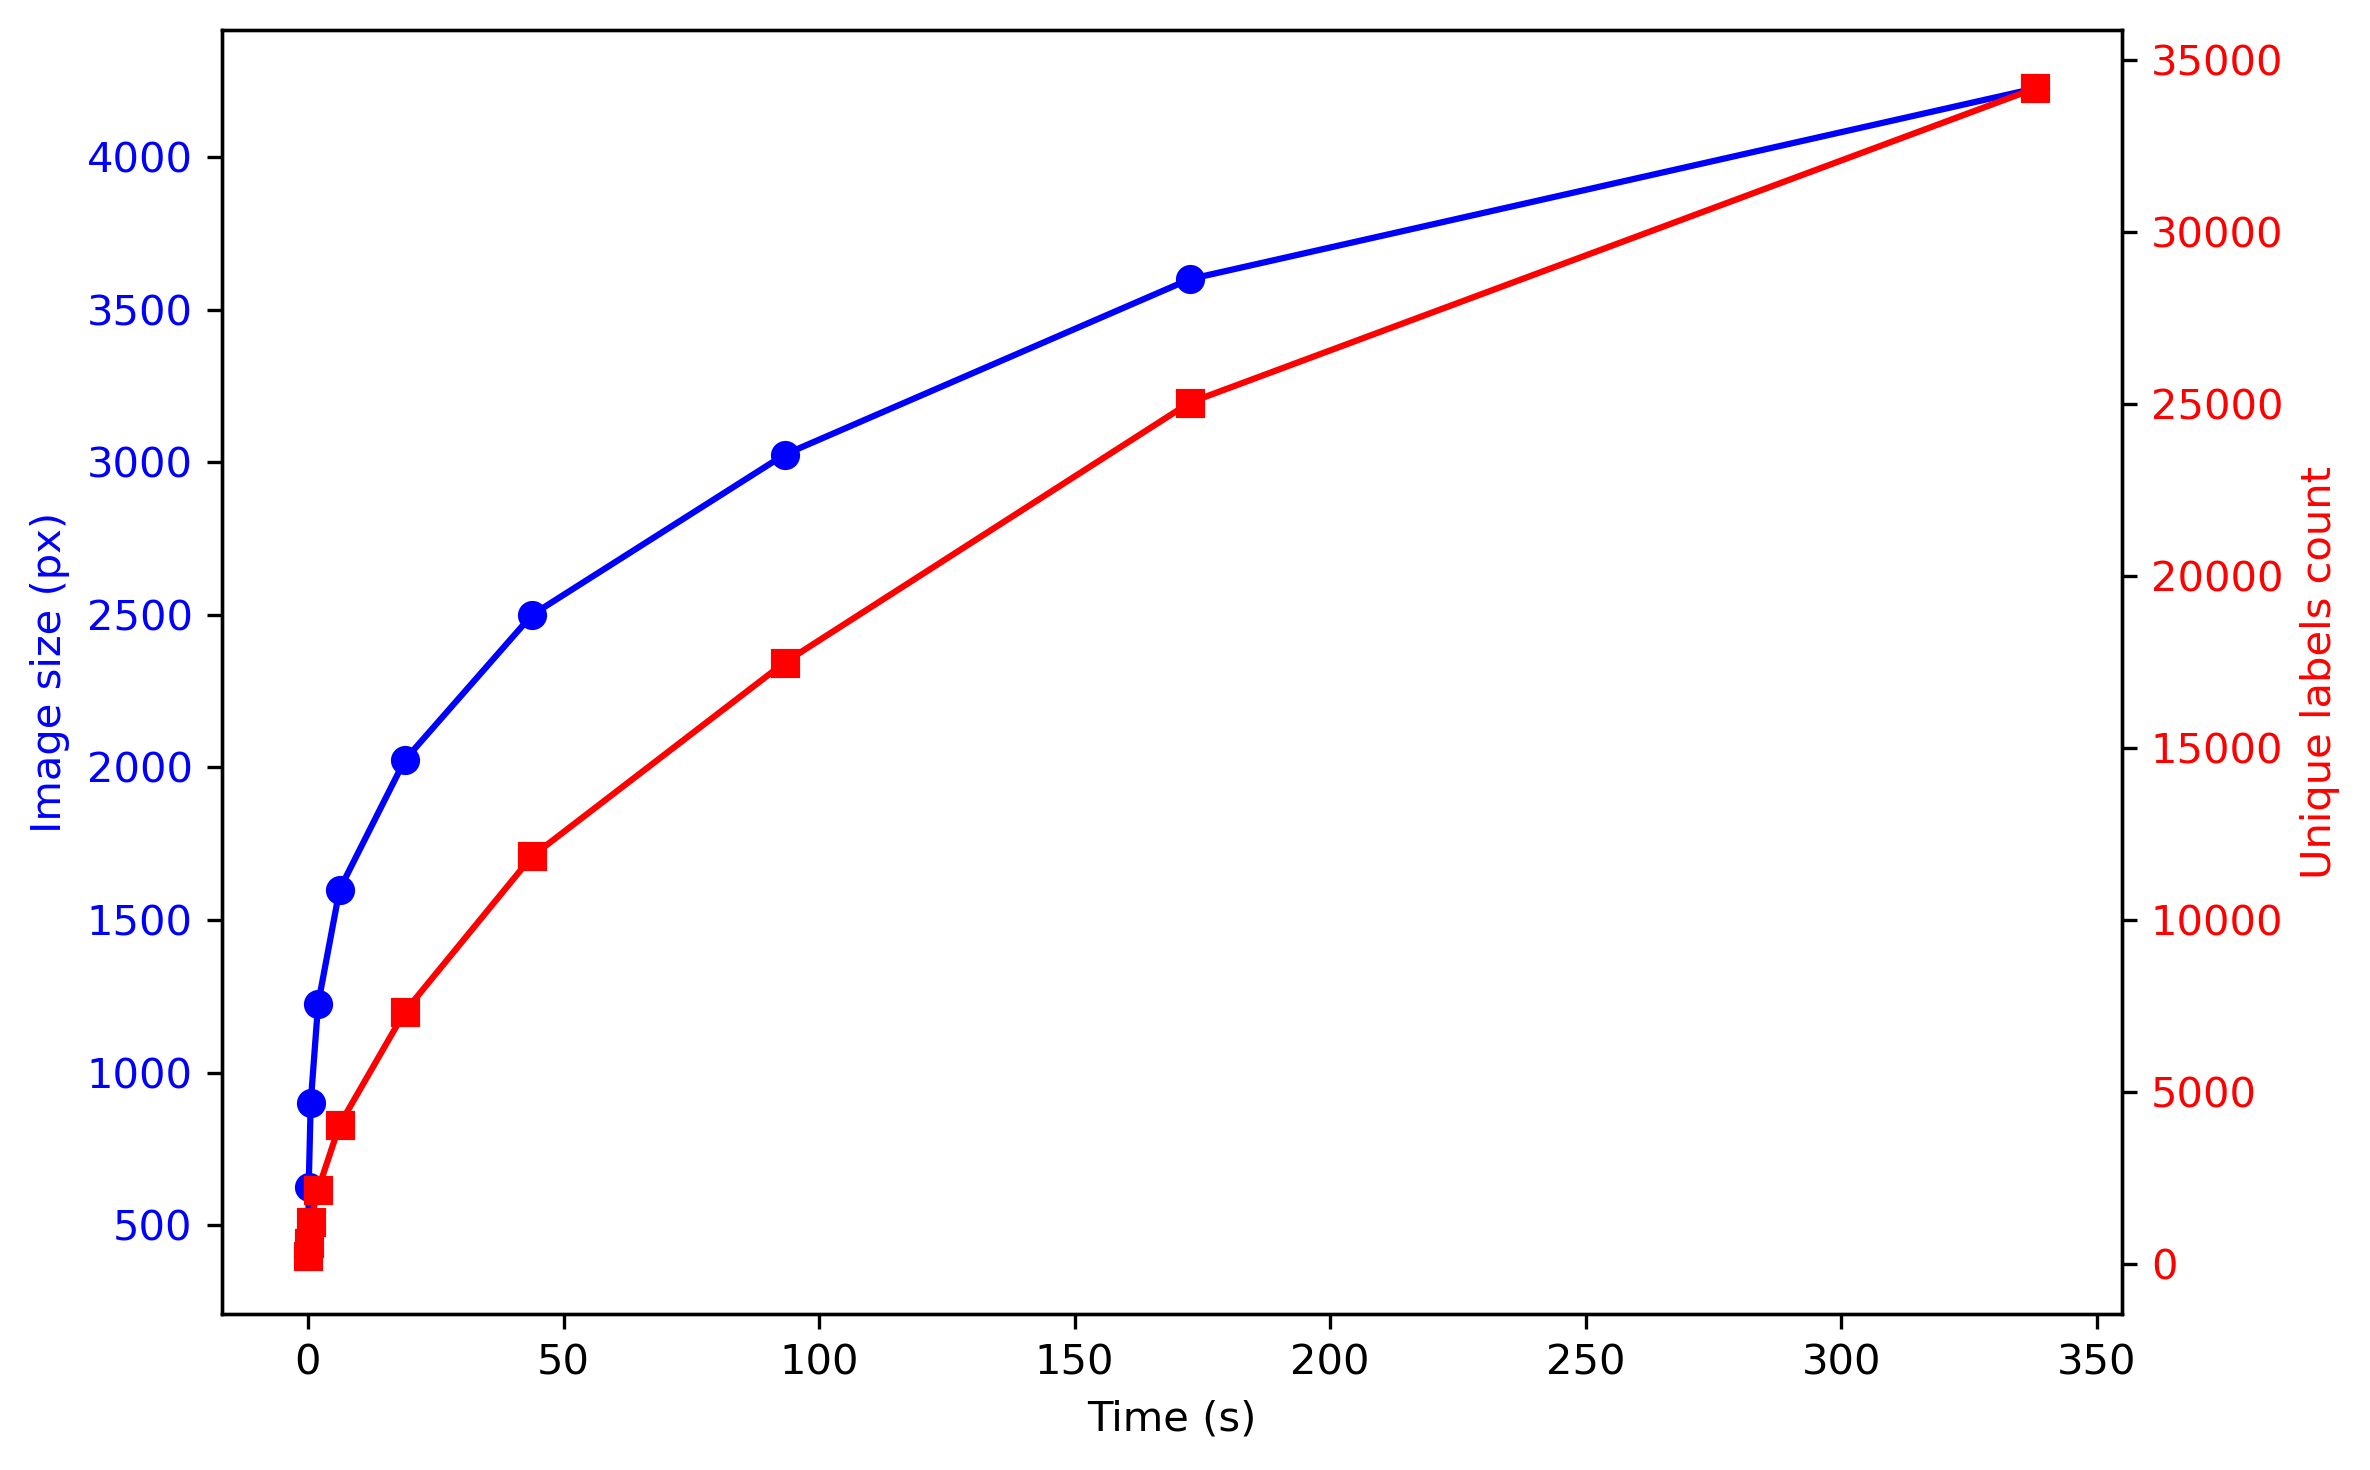

In [ ]:
#| eval: false
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot vector vs. timings on the left y-axis (x-axis is time)
ax1.plot(timings, vector, marker='o', color='blue', label='Vector')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Image size (px)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis and plot n_labels vs. timings on it
ax2 = ax1.twinx()
ax2.plot(timings, n_labels, marker='s', color='red')
ax2.set_ylabel('Unique labels count', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.tight_layout()
plt.savefig('../data/runtime_eval.png', dpi=300)
plt.show()

This is probably the most time-consuming step when working with large whole-slide scans. Regardless of how many labels you have, `expand_with_cap` computes the exact Euclidean distance for every background pixel. Since time complexity is a function of $K$ (number of unique labels) and $N$ (number of pixels), and $K$ grows proportionally with $N$, the overall time complexity is $O(N^2)$.   

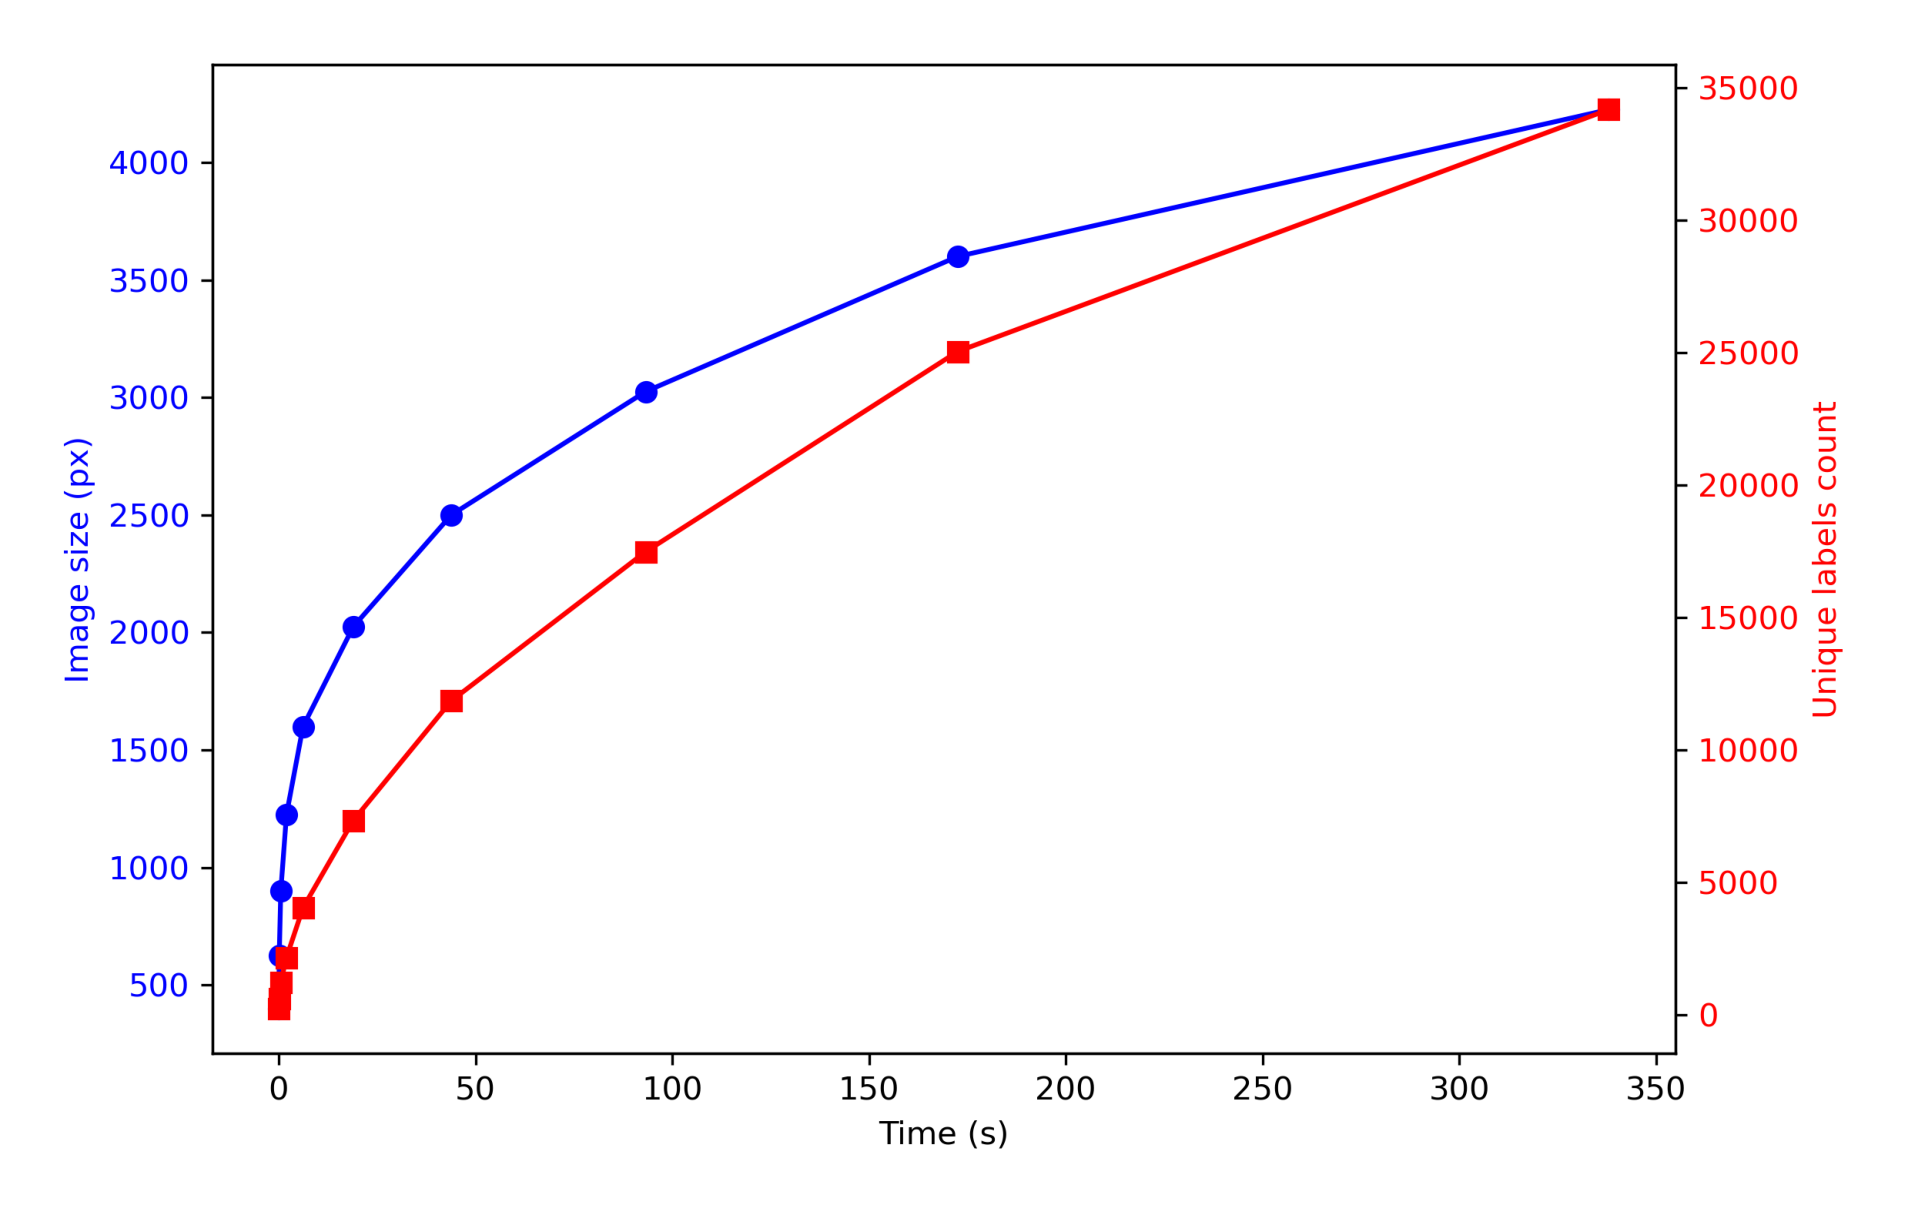

In [ ]:
img = plt.imread('../data/runtime_eval.png')
plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.axis('off')
plt.show()